# Train/ Test Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 2 - Load the data

In [2]:
spy = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed
spy.columns = spy.columns.str.strip()

spy = pd.DataFrame({'Adj_Close': spy['Close']})

spy.sort_index(inplace=True)
spy.head()

,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


In [3]:
short_window = 50
long_window = 200
transaction_cost = 0.001

spy["simple_return"] = spy["Adj_Close"].pct_change()
spy["ma_short"] = spy["Adj_Close"].rolling(short_window).mean()
spy["ma_long"] = spy["Adj_Close"].rolling(long_window).mean()
spy["signal_raw"] = (spy["ma_short"] > spy["ma_long"]).astype(int)
spy["signal"] = spy["signal_raw"].shift(1)
spy["trade"] = spy["signal"].diff().abs().fillna(0)
spy["strategy_return_net"] = spy["signal"] * spy["simple_return"] - spy["trade"] * transaction_cost
spy["equity_net"] = (1 + spy["strategy_return_net"]).cumprod()
spy["equity_bh"] = (1 + spy["simple_return"]).cumprod()

spy = spy.dropna(subset=["strategy_return_net"])

Step 3 - Choose a split point

- Picking a split date so you can separate in-sample from out-of-sample data
- A simple rule is to split around 70/30 or 80/20

In [5]:
split_date = "2021-01-01"   # change if your dataset starts/ends differently

train = spy.loc[spy.index < split_date].copy()
test = spy.loc[spy.index >= split_date].copy()

print("Train period:", train.index.min(), "to", train.index.max(), "rows:", len(train))
print("Test period:", test.index.min(), "to", test.index.max(), "rows:", len(test))

Train period: 1993-02-01 00:00:00 to 2020-12-31 00:00:00 rows: 7036
Test period: 2021-01-04 00:00:00 to 2026-03-13 00:00:00 rows: 1304


Step 4 - Build a fresh test signal from the chosen parameters

- For a clean out-of-sample test, you want to use the same strategy rules on the test set wihtout changing them.

In [6]:
def build_ma_strategy(df, short_window=50, long_window=200, transaction_cost=0.001):
    temp = df.copy()
    temp["simple_return"] = temp["Adj_Close"].pct_change()
    temp["ma_short"] = temp["Adj_Close"].rolling(short_window).mean()
    temp["ma_long"] = temp["Adj_Close"].rolling(long_window).mean()
    temp["signal_raw"] = (temp["ma_short"] > temp["ma_long"]).astype(int)
    temp["signal"] = temp["signal_raw"].shift(1)
    temp["trade"] = temp["signal"].diff().abs().fillna(0)
    temp["strategy_return_net"] = temp["signal"] * temp["simple_return"] - temp["trade"] * transaction_cost
    temp = temp.dropna(subset=["strategy_return_net"])
    temp["equity_net"] = (1 + temp["strategy_return_net"]).cumprod()
    temp["equity_bh"] = (1 + temp["simple_return"]).cumprod()
    return temp

In [7]:
train_bt = build_ma_strategy(train, short_window, long_window, transaction_cost)
test_bt = build_ma_strategy(test, short_window, long_window, transaction_cost)

Step 5 - Define the performance functions again

In [10]:
def annualized_return(r):
    return (1 + r.mean())**252 - 1

def annualized_vol(r):
    return r.std() * np.sqrt(252)

def sharpe_ratio(r):
    vol = annualized_vol(r)
    return np.nan if vol == 0 else annualized_return(r) / vol

def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

Step 6 - Compare in-sample  and out-of-sample

In [11]:
results = pd.DataFrame({
    "Train": [
        annualized_return(train_bt["strategy_return_net"]),
        annualized_vol(train_bt["strategy_return_net"]),
        sharpe_ratio(train_bt["strategy_return_net"]),
        max_drawdown(train_bt["equity_net"]),
        train_bt["trade"].sum()
    ],
    "Test": [
        annualized_return(test_bt["strategy_return_net"]),
        annualized_vol(test_bt["strategy_return_net"]),
        sharpe_ratio(test_bt["strategy_return_net"]),
        max_drawdown(test_bt["equity_net"]),
        test_bt["trade"].sum()
    ]
}, index=["Annual Return", "Annual Volatility", "Sharpe", "Max Drawdown", "Trade Count"])

results

,Train,Test
Annual Return,0.084923,0.057934
Annual Volatility,0.134863,0.123066
Sharpe,0.629700,0.470758
Max Drawdown,-0.341047,-0.194514
Trade Count,27.000000,5.000000


Does test performance collapse?
- Performance decreases, wouldn't say it collapses - bad sign

Is Sharpe much worse out of sample?
- Sharpe has decreased, not drastically however with costs this can take the edge from the strategy - bad sign
  
Are trades still frequent?
- Trades are definitely not as frequent, big drop in no. of trades - huge bad sign
  
Is max drawdown worse in the test period?
- Max drawdown is better during the test period - good sign

Step 7 - Plot train vs test equity curves

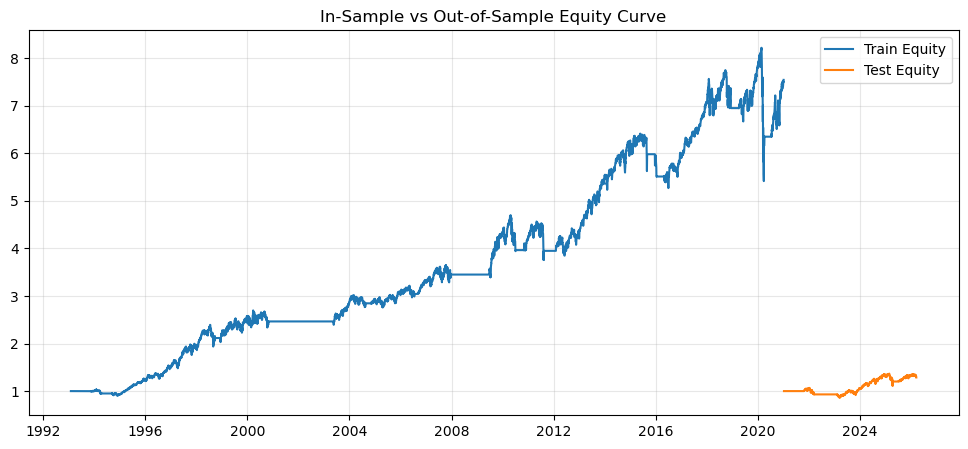

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train_bt.index, train_bt["equity_net"], label="Train Equity")
plt.plot(test_bt.index, test_bt["equity_net"], label="Test Equity")
plt.title("In-Sample vs Out-of-Sample Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Does the shape change dramatically in the test period?
- Shape definitely changes and not same progress as in the training period as the test period

Does the strategy still trend upward?
- It seems the strategy trends upwards
  
Or does it flatten and draw down quickly?
- Wouldn't say it flattens out and drawdowns quickly

Step 8 - Compare to buy-and-hold in both periods

In [14]:
comparison = pd.DataFrame({
    "Train Buy & Hold": [
        annualized_return(train_bt["simple_return"]),
        annualized_vol(train_bt["simple_return"]),
        sharpe_ratio(train_bt["simple_return"]),
        max_drawdown(train_bt["equity_bh"])
    ],
    "Train Strategy": [
        annualized_return(train_bt["strategy_return_net"]),
        annualized_vol(train_bt["strategy_return_net"]),
        sharpe_ratio(train_bt["strategy_return_net"]),
        max_drawdown(train_bt["equity_net"])
    ],
    "Test Buy & Hold": [
        annualized_return(test_bt["simple_return"]),
        annualized_vol(test_bt["simple_return"]),
        sharpe_ratio(test_bt["simple_return"]),
        max_drawdown(test_bt["equity_bh"])
    ],
    "Test Strategy": [
        annualized_return(test_bt["strategy_return_net"]),
        annualized_vol(test_bt["strategy_return_net"]),
        sharpe_ratio(test_bt["strategy_return_net"]),
        max_drawdown(test_bt["equity_net"])
    ]
}, index=["Annual Return", "Annual Volatility", "Sharpe", "Max Drawdown"])

comparison

,Train Buy & Hold,Train Strategy,Test Buy & Hold,Test Strategy
Annual Return,0.098921,0.084923,0.136118,0.057934
Annual Volatility,0.189081,0.134863,0.169899,0.123066
Sharpe,0.523169,0.629700,0.801172,0.470758
Max Drawdown,-0.564737,-0.341047,-0.253606,-0.194514


## Interpretation

Did the strategy hold up out of sample?
- Yes, returns don't diminish drastically and volatility gets better

Was performance weaker, similar, or stronger than in sample?
- Performance is weaker in the sample

Did buy-and-hold outperform the strategy in the test period?
- Yes, huge outperformance from Buy and Hold during the test period

Did transaction costs matter more out of sample?
- Yes, can notice a clear decrease in the test strategy

Would you trust this result enough to keep going?
- Yes